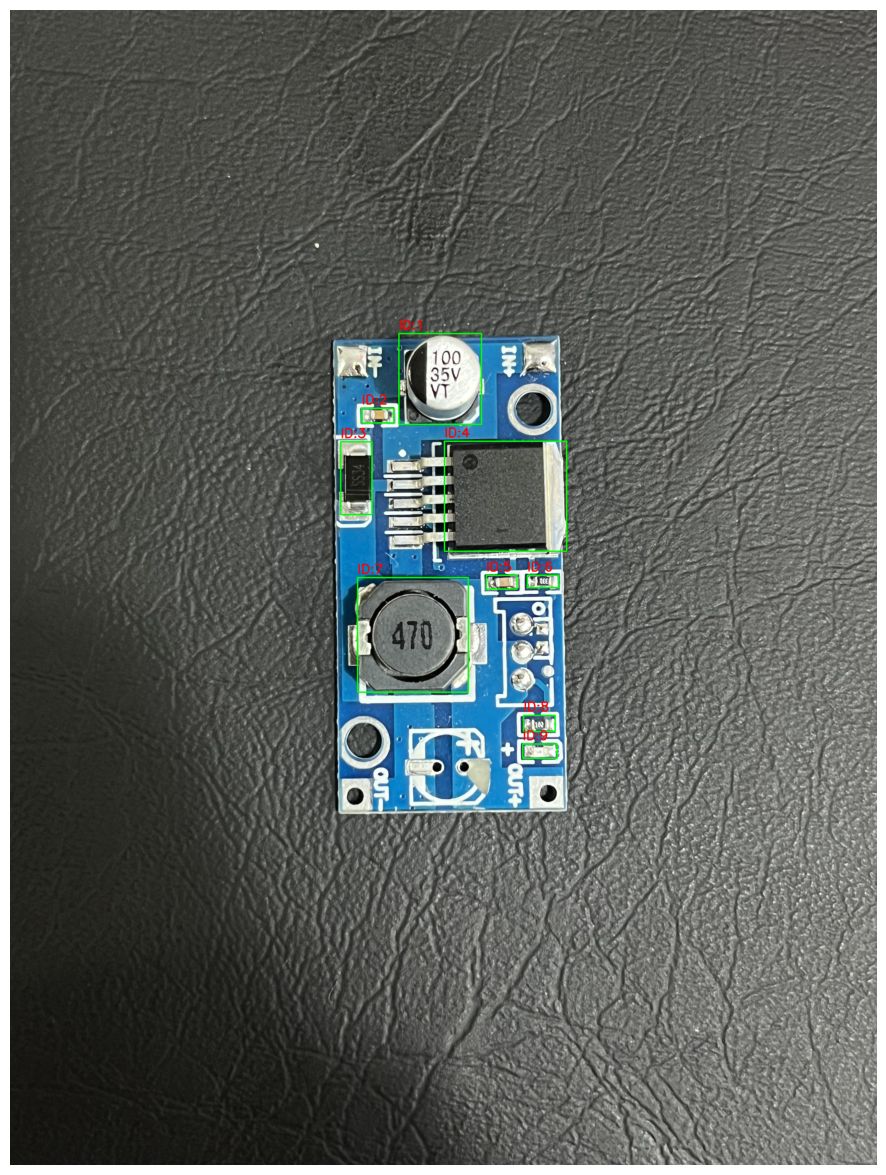

In [1]:
import cv2
import matplotlib.pyplot as plt
import os

def draw_yolo_labels(image_path, label_text):
    if not os.path.exists(image_path):
        print(f"❌ Không tìm thấy file tại: {image_path}")
        return

    img = cv2.imread(image_path)
    if img is None:
        print("❌ Lỗi: OpenCV không đọc được ảnh.")
        return

    h, w, _ = img.shape
    lines = label_text.strip().split('\n')
    
    for i, line in enumerate(lines):
        data = line.split()
        x_c, y_c, wb, hb = map(float, data[1:])
        
        x1 = int((x_c - wb/2) * w)
        y1 = int((y_c - hb/2) * h)
        x2 = int((x_c + wb/2) * w)
        y2 = int((y_c + hb/2) * h)
        
        # Vẽ box màu xanh lá dày hơn (thickness=3)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # CHỈNH CHỮ TẠI ĐÂY:
        # fontScale=1.5 (to hơn), thickness=4 (đậm hơn)
        # Màu đỏ (0, 0, 255) cho nổi bật
        text = f"ID:{i+1}"
        cv2.putText(img, text, (x1, y1-15), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 4)

    # Tăng kích thước hiển thị của Matplotlib lên 15x15 cho rõ
    plt.figure(figsize=(15, 15))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Giữ nguyên đường dẫn và labels của bạn
path = 'C:\\Users\\LENOVO\\Downloads\\dataset_lm2596-20251229T055104Z-3-001\\dataset_lm2596\\valid\\images\\0066.png' 

labels = """
0 0.496184 0.319330 0.095136 0.078602
0 0.424196 0.351190 0.036630 0.012592
0 0.399522 0.405372 0.036121 0.062958
0 0.571479 0.421016 0.140924 0.095009
0 0.567155 0.495421 0.035613 0.011828
0 0.614723 0.494849 0.036121 0.010684
0 0.464642 0.541018 0.127696 0.099206
0 0.610653 0.617712 0.036121 0.013736
0 0.611416 0.641751 0.039683 0.012210


"""

draw_yolo_labels(path, labels)